In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import csv
import pandas as pd
import os
import math

In [ ]:
G = nx.DiGraph()

with open("D:/SEM VI/Project/Dataset/edges.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        G.add_edge(
            int(row["u"]), 
            int(row["v"]),
            trust = float(row["trust"])
        )


with open("D:/SEM VI/Project/Dataset/nodes1.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        node = int(row["node"])
        threshold = float(row["threshold"])
        opinion = row["opinion"].strip() if row["opinion"] else None

        G.add_node(node)
        G.nodes[node]["threshold"] = threshold
        G.nodes[node]["opinion"] = opinion

In [ ]:
opinion_colors = {
    "A": "red",
    "B": "blue",
    "C": "green",
    "U": "lightgray"
}

opinion_weight = {
    "A": 0.9,
    "B": 0.6,
    "C": 0.4
}

belief_value = {
    "A": 1.0,
    "B": 0.5,
    "C": 0.0
}

ALPHA = 0.6
BETA = 0.3
GAMMA = 0.4

In [ ]:
CONFIRMATION_BIAS = True

def resistance(node, new_op, prev_op):
    if prev_op is None or prev_op == new_op:
        return 0.0
    return 1.0

# Opinion update step
def directed_multi_opinion_step(G):
    prev_opinion = {
        n: G.nodes[n]["opinion"] for n in G.nodes()
    }
    updates = {}

    for v in G.nodes():
        incoming = list(G.predecessors(v))
        if not incoming:
            continue

        weighted_sum = {}
        total_trust = 0.0

        for u in incoming:
            op_u = prev_opinion[u]
            if op_u == "U":
                continue

            trust = G[u][v]["trust"]

            # Confirmation Bias
            if CONFIRMATION_BIAS and prev_opinion[v] != "U":
                diff = abs(belief_value[op_u] - belief_value[prev_opinion[v]])
                confirmation_weight = math.exp(-ALPHA * diff)
                trust *= confirmation_weight

            weighted_sum[op_u] = weighted_sum.get(op_u, 0) + trust * opinion_weight[op_u]
            total_trust += trust

        if total_trust == 0:
            continue


        # APPROACH 1 & 2 FORMULA
        scores = {
            op: val / total_trust
            for op, val in weighted_sum.items()
        }

        valid_ops = [
            op for op, score in scores.items()
            if score >= G.nodes[v]["threshold"]
        ]

        if valid_ops:
            updates[v] = max(valid_ops, key=lambda o: scores[o])

    return updates, prev_opinion

In [32]:
def export_to_excel(G, iteration, prev_opinion,
                    out_dir="D:/SEM VI/Project/Dataset/updateexcel"):
    os.makedirs(out_dir, exist_ok=True)

    node_rows = []
    for n in G.nodes():
        node_rows.append({
            "node": n,
            "opinion_changed": prev_opinion.get(n) != G.nodes[n]["opinion"],
            "threshold": G.nodes[n]["threshold"],
            "iteration": iteration
        })

    pd.DataFrame(node_rows).to_excel(
        f"{out_dir}/nodes_iter_{iteration}.xlsx",
        index=False
    )

    edge_rows = [{"source": u, "target": v} for u, v in G.edges()]
    pd.DataFrame(edge_rows).to_excel(
        f"{out_dir}/edges_iter_{iteration}.xlsx",
        index=False
    )

In [33]:
pos = nx.spring_layout(G, seed=42)

def plot_iteration(G, iteration):
    colors = [opinion_colors[G.nodes[n]["opinion"]] for n in G.nodes()]
    labels = {n: f"{n}\n{G.nodes[n]['opinion']}" for n in G.nodes()}

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, node_color=colors, node_size=800, edge_color="gray", arrows=True)
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    plt.title(f"Iteration {iteration}")
    plt.show()

Iteration 1: 17 real opinion changes


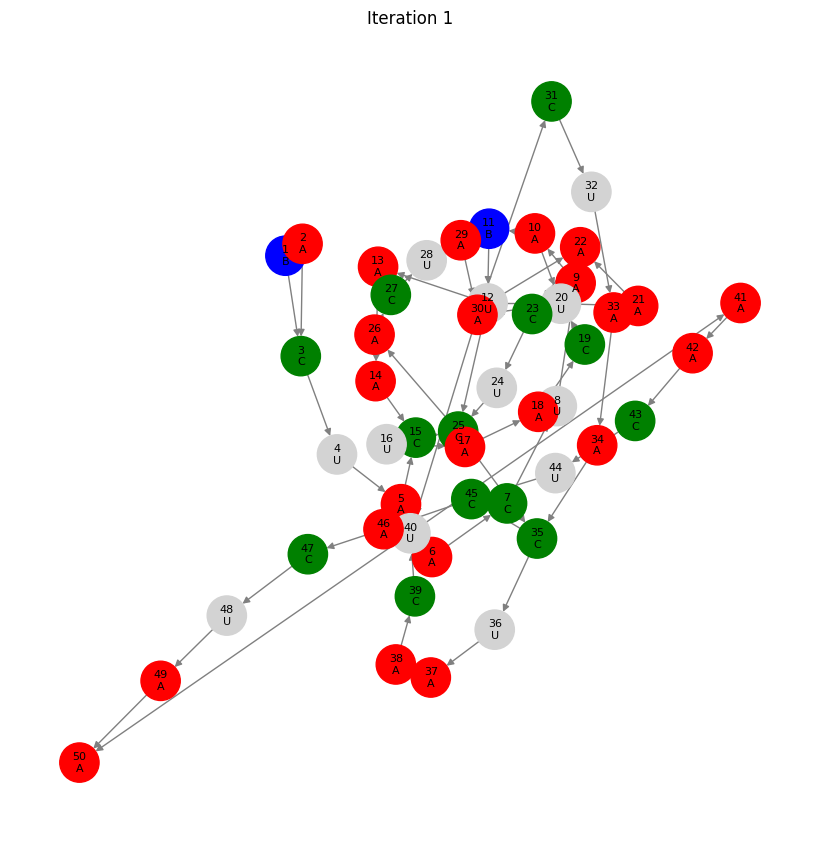

Iteration 2: 13 real opinion changes


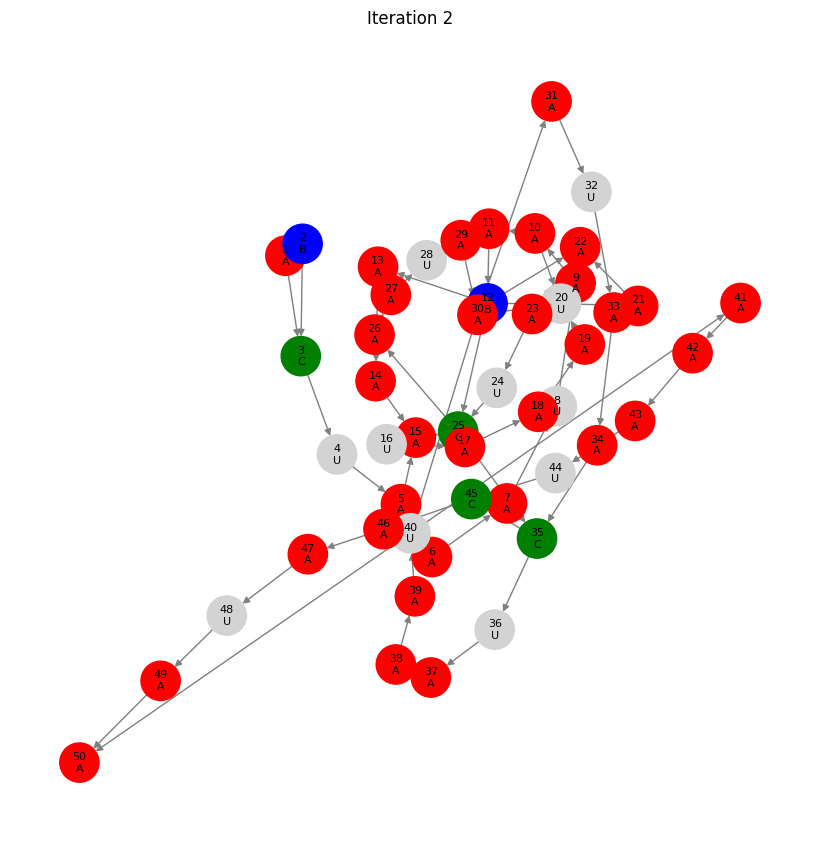

Iteration 3: 14 real opinion changes


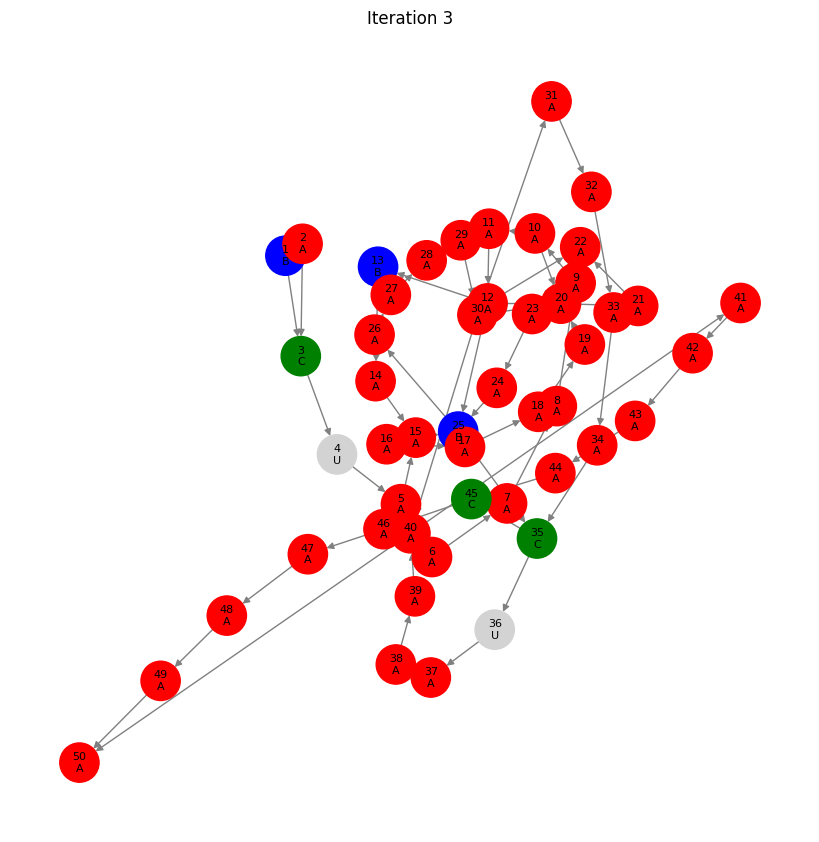

Iteration 4: 6 real opinion changes


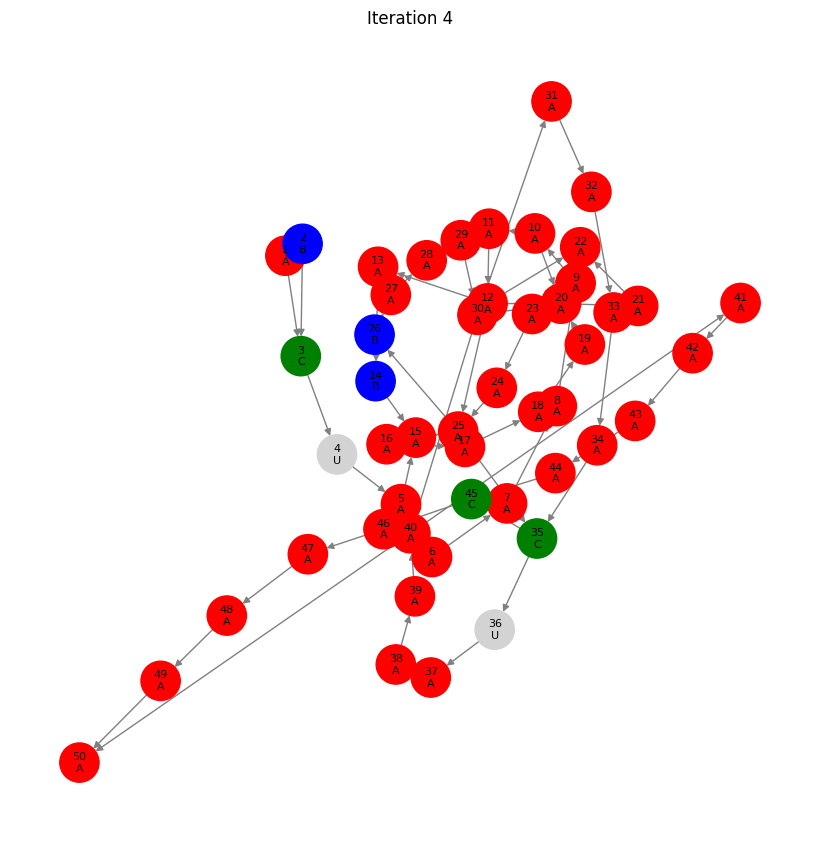

Iteration 5: 5 real opinion changes


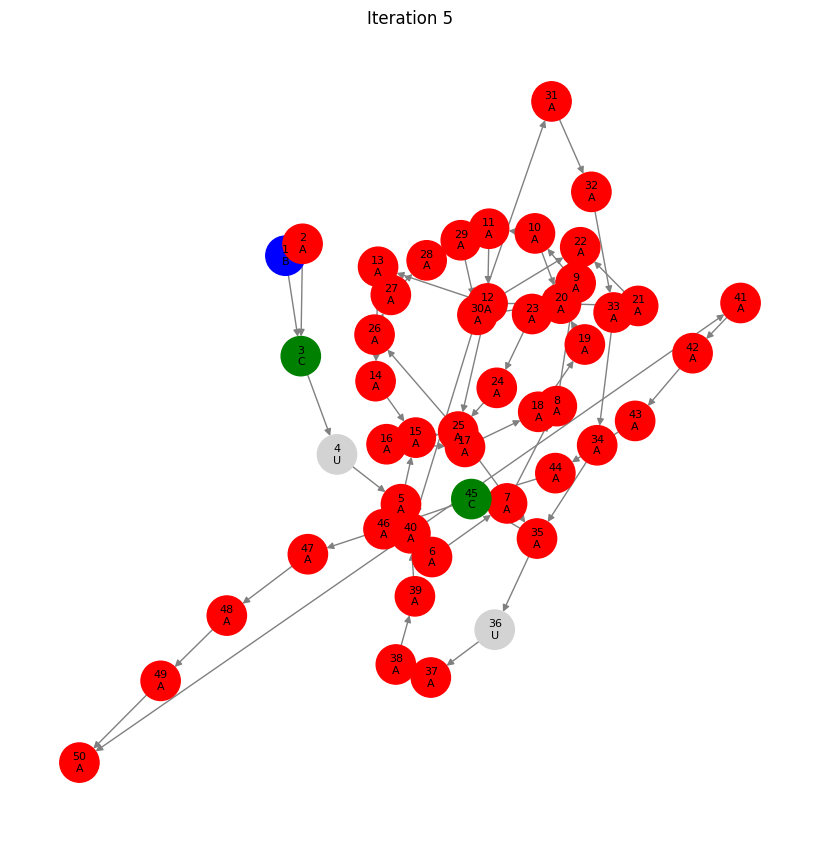

Iteration 6: 4 real opinion changes


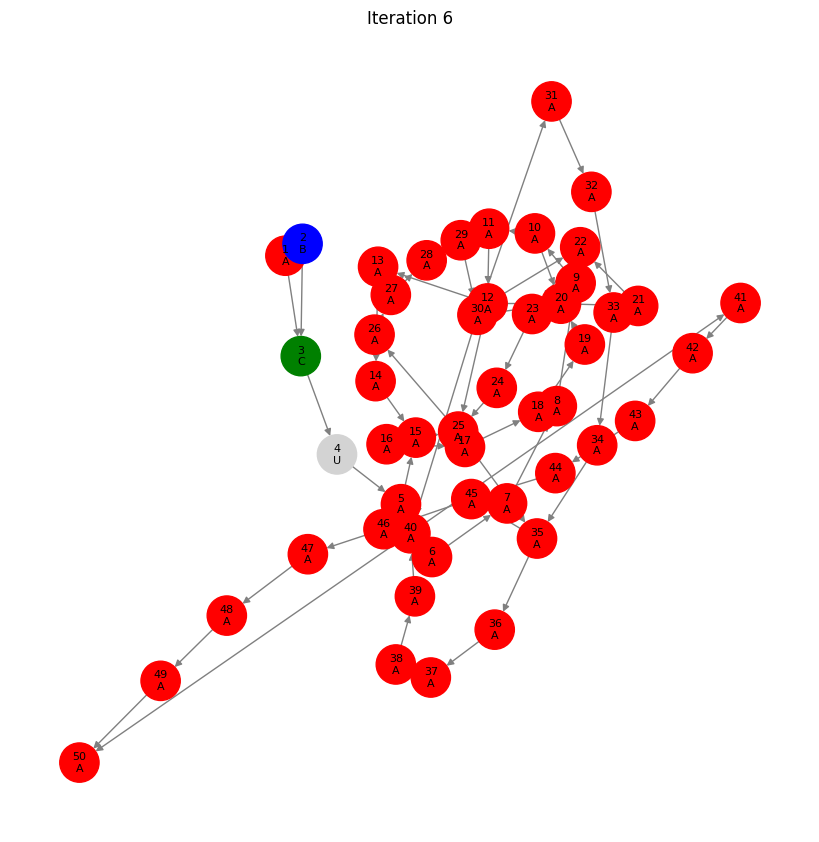

Iteration 7: 2 real opinion changes


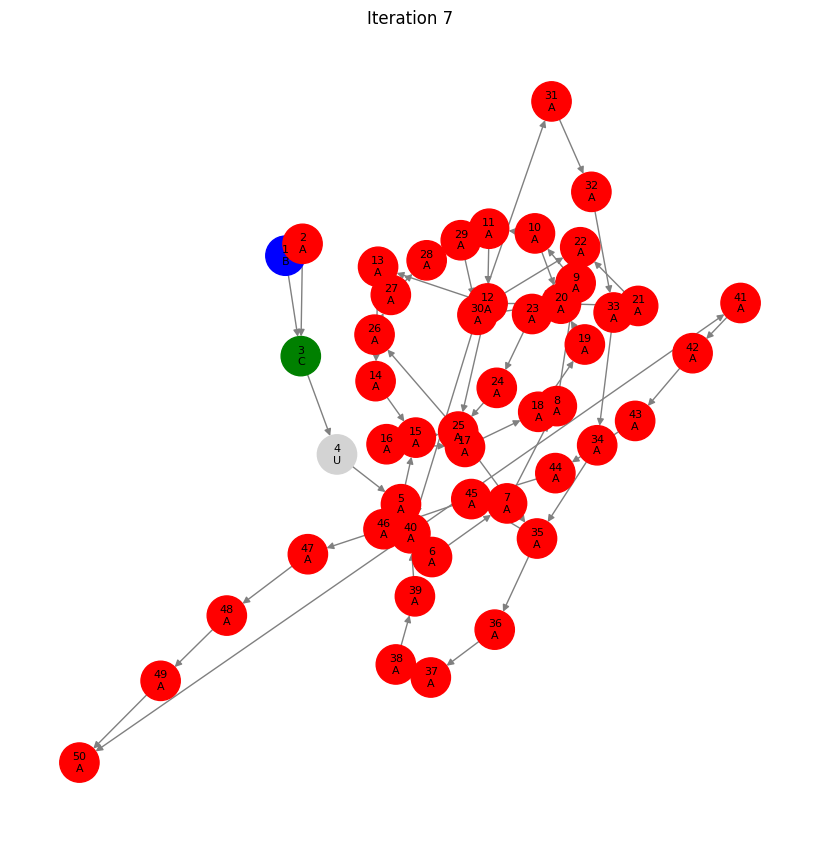

Iteration 8: 2 real opinion changes


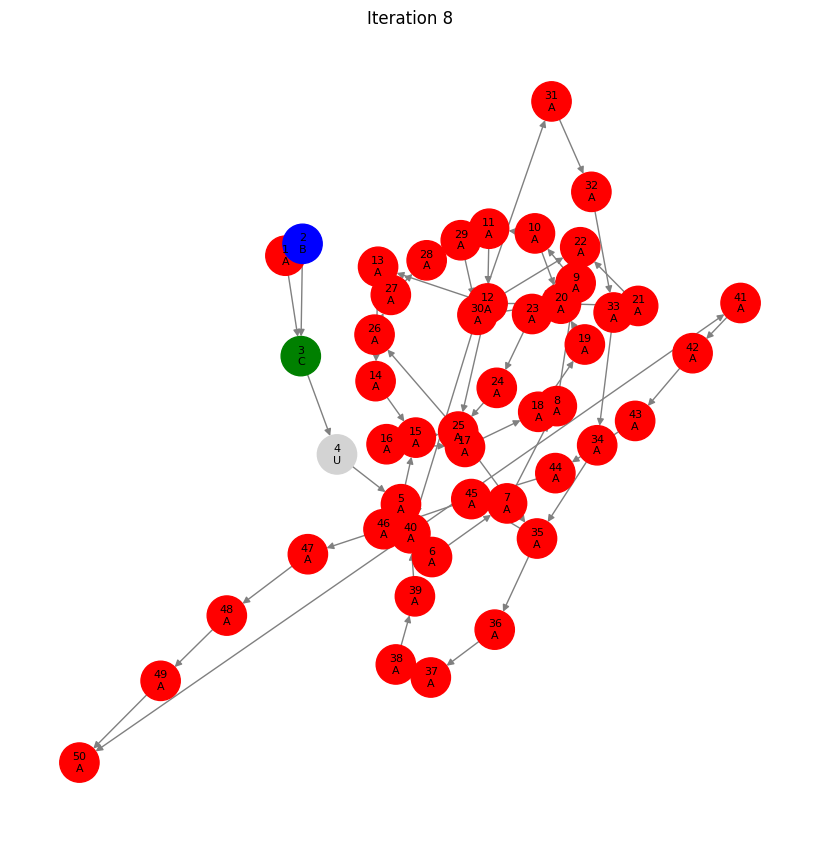

Iteration 9: 2 real opinion changes


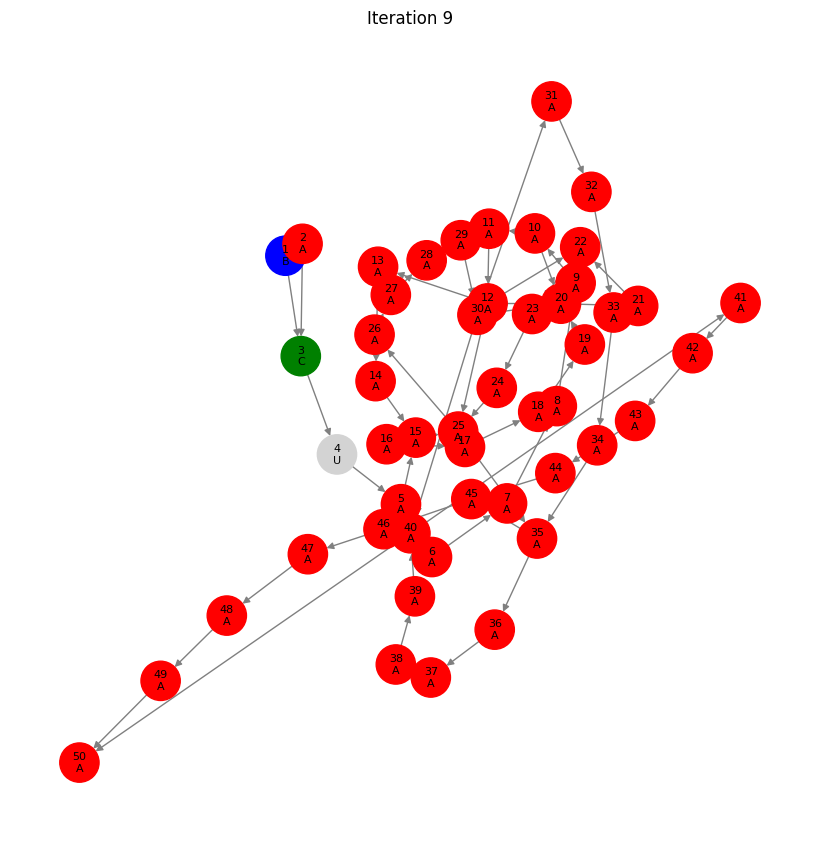

Iteration 10: 2 real opinion changes


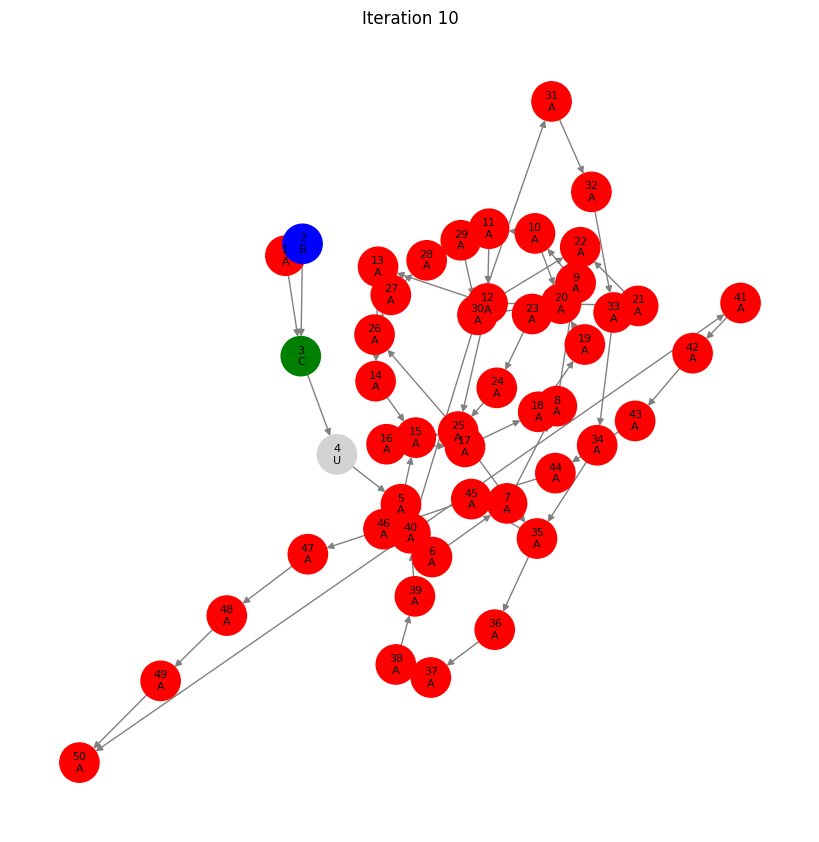

In [ ]:
MAX_ITER = 10

for i in range(1, MAX_ITER + 1):
    updates, prev_opinion = directed_multi_opinion_step(G)

    real_changes = {
        node: op for node, op in updates.items()
        if prev_opinion[node] != op
    }

    print(f"Iteration {i}: {len(real_changes)} real opinion changes")

    if not real_changes:
        print("No new opinion changes. Converged.")
        export_to_excel(G, i, prev_opinion)
        plot_iteration(G, i)
        break

    for node, op in real_changes.items():
        G.nodes[node]["opinion"] = op

    export_to_excel(G, i, prev_opinion)
    plot_iteration(G, i)